In [1]:
import math
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, PercentFormatter
import numpy as np
import pandas as pd

import seaborn as sn


In [6]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MultipleLocator, PercentFormatter

# Formule native Wilson Score (evite les erreurs d'import)
def wilson_score_interval(successes, total_trials):
    if total_trials == 0:
        return 0.0, 0.0
    p = successes / total_trials
    z = 1.95996  # 95%
    denominator = 1 + (z**2) / total_trials
    centre = (p + (z**2) / (2 * total_trials)) / denominator
    half_width = (
        z
        * math.sqrt(
            (p * (1 - p) + (z**2) / (4 * total_trials)) / total_trials
        )
    ) / denominator
    return max(0.0, centre - half_width), min(1.0, centre + half_width)


def plot_bar(successes, categories, total_trials, name="lollll"):
    labels = list(successes.keys())
    df = pd.DataFrame(successes, index=categories).T
    total_counts = df.sum(axis=1)
    total_counts_without_miss = df.drop(columns=["GRASP_FAILURE"]).sum(axis=1)
    df_perc = (df / total_trials) * 100

    lower_errors, upper_errors, total_rates = [], [], []

    for total_success in total_counts_without_miss:
        lower_prop, upper_prop = wilson_score_interval(
            total_success, total_trials
        )
        current_rate = (total_success / total_trials) * 100
        total_rates.append(current_rate)
        lower_errors.append(current_rate - (lower_prop * 100))
        upper_errors.append((upper_prop * 100) - current_rate)

    asymmetric_error = [lower_errors, upper_errors]

    # --- DEFINITION DES DEUX PALETTES ---
    cmap_blue = cm.Blues
    blue_colors = [
        cmap_blue(i) for i in np.linspace(0.20, 0.90, len(categories) - 1)
    ] + [cmap_blue(0.05)]

    cmap_red = cm.Reds
    red_colors = [
        cmap_red(i) for i in np.linspace(0.20, 0.90, len(categories) - 1)
    ] + [cmap_red(0.05)]

    fig, ax = plt.subplots(figsize=(9, 6), dpi=150)

    # Tracé initial (utilise le bleu pour générer la légende proprement)
    df_perc.plot.bar(
        stacked=True,
        ax=ax,
        rot=30,
        color=blue_colors,
        edgecolor="black",
        linewidth=0.7,
    )

    # --- RECOLORISATION SPECIFIQUE POUR "_CHEAP" ---
    # ax.containers contient les segments (catégories) de la barre empilée.
    for cat_idx, container in enumerate(ax.containers):
        for bar_idx, patch in enumerate(container):
            sensor_name = labels[bar_idx]
            
            # Si le capteur finit par "_CHEAP", on applique la palette rouge
            if sensor_name.endswith("_CHEAP"):
                patch.set_facecolor(red_colors[cat_idx])
            else:
                patch.set_facecolor(blue_colors[cat_idx])
                
            # Rendre la catégorie "MISS" (le dernier conteneur) semi-transparente
            if cat_idx == len(ax.containers) - 1:
                patch.set_alpha(0.4)

    ax.set_axisbelow(True)
    ax.yaxis.set_major_locator(MultipleLocator(20))
    ax.yaxis.set_major_formatter(PercentFormatter())
    plt.grid(axis="y", linestyle="--", alpha=0.6, color="gray")

    x_positions = range(len(labels))

    # Barres d'erreur
    ax.errorbar(
        x=x_positions,
        y=total_rates,
        yerr=asymmetric_error,
        fmt="o",             
        markersize=6.5,      
        markerfacecolor="#ffffff",  
        markeredgecolor="#111111",  
        markeredgewidth=1.8,
        ecolor="#222222",
        capsize=7,
        capthick=1.5,
        elinewidth=1.5,
        zorder=3,            
    )

    # Placement du texte "n = ..." 
    bolt_top_positions = df_perc[
        ["EMPTY", "SPACER", "7_SPACERS", "7_NUTS"]
    ].sum(axis=1)

    for i, x in enumerate(x_positions):
        total_count = total_counts_without_miss.iloc[i]
        bolt_top_y = bolt_top_positions.iloc[i]
        y_position = bolt_top_y + 2

        ax.text(
            x,
            y_position,
            f"n = {total_count}/{total_trials}, {int(total_count/total_trials*100)}%",
            ha="center",
            va="bottom",
            color="#FFFFFF",
            fontweight="bold",
            fontsize=8.5,
            bbox=dict(
                facecolor="#111111",
                edgecolor="none",
                alpha=0.85,
                boxstyle="round,pad=0.25",
            ),
            zorder=4,
        )

    ax.set_ylim(0, 100)
    plt.ylabel("Success Rate (%)", fontsize=11)
    plt.xlabel("Sensor type", fontsize=11, labelpad=10)
    plt.title(
        f"Success Rate with Wilson Score Error Bars (N={total_trials})",
        fontsize=12,
        fontweight="bold",
        pad=15,
    )
    plt.legend(title="Box type", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"outputs_svg/{name}_success_rate_plot.svg", format="svg", bbox_inches="tight")
    plt.show()

NameError: name 'ticker' is not defined

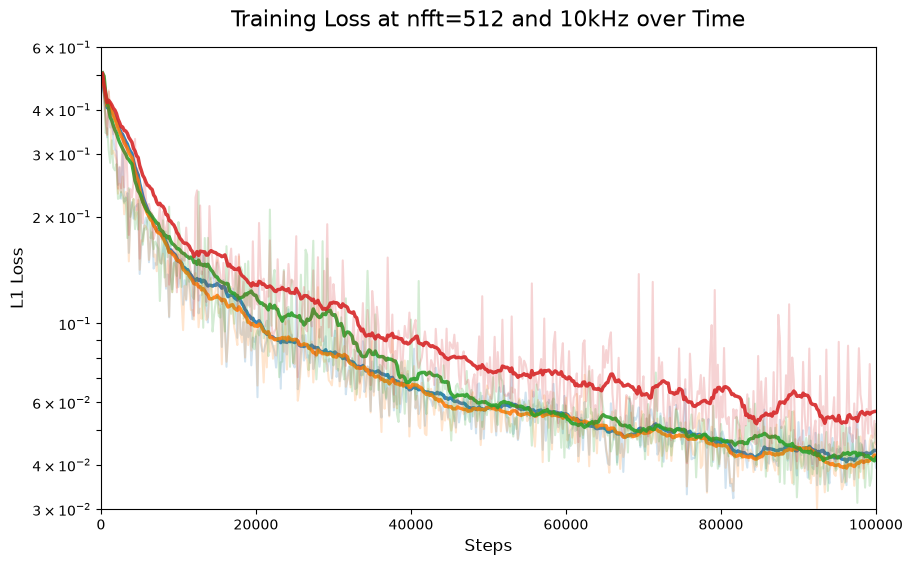

In [3]:


# 1. Load data
file_path = 'wandb_export_2026-08-18T14_40_20.276+02_00.csv'
df = pd.read_csv(file_path)

# 2. Prepare data mapping
steps = df['Step'] 
sensor_metrics = {
    "DGF": df['2026-07-28_shake4it_bench_dragonfly_10kHz_nfft_512 - train/l1_loss'],
    "ACCELERO": df['2026-07-28_shake4it_bench_accelero_10kHz_nfft_512 - train/l1_loss'],
    "LOAD CELL": df['2026-08-06_shake4it_bench_dlc_load_cell_10kHz_nfft_512 - train/l1_loss'],
    "NOTACT": df['2026-07-28_shake4it_bench_notact - train/l1_loss']
}

# 3. Setup the plot with a pure white background
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')  # Surrounding figure background
ax.set_facecolor('white')         # Inner plot background

window_size = 20
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# 4. Plot raw and smoothed data
for i, (label, y_data) in enumerate(sensor_metrics.items()):
    smoothed_loss = y_data.rolling(window=window_size, min_periods=1).mean()
    ax.plot(steps, y_data, color=colors[i], alpha=0.2)
    ax.plot(steps, smoothed_loss, color=colors[i], alpha=0.9, linewidth=2.5, label=label)

# 5. Labels and limits
ax.set_title('Training Loss at nfft=512 and 10kHz over Time', fontsize=16, pad=15)
ax.set_xlabel('Steps', fontsize=12)
ax.set_ylabel('L1 Loss', fontsize=12)

ax.set_yscale('log')
ax.set_xlim(0, 100_000)
ax.set_ylim(3e-2, 0.6)

# 6. Force multiple Y-axis tick values
# Because the log range is narrow (0.03 to 0.6), default log ticks often only show 10^-1.
# This manually sets ticks and formats them as standard numbers rather than scientific notation.
y_ticks = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
ax.set_yticks(y_ticks)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g')) 
ax.tick_params(axis='both', which='major', length=3, width=1, labelsize=9)
ax.set_yticks([], minor=True)

decades = ['0.01', '0.1', '1', '10']  # Liste des décades possibles
for tick_label in ax.get_yticklabels():
    if tick_label.get_text() in decades:
        tick_label.set_fontweight('bold')
        tick_label.set_fontsize(12)

# 7. Add a rectangle frame ("encadrer") and styling
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)  # Make the rectangle frame prominent

# Subtler grid to keep the background looking clean
ax.grid(True, axis='both', linestyle='--',color='gray', alpha=0.3)

# Add frame to the legend as well to match the rectangle aesthetic
ax.legend(title="Sensor type", frameon=True, edgecolor='black', fontsize=12)

# 8. Display
plt.tight_layout()
plt.show()

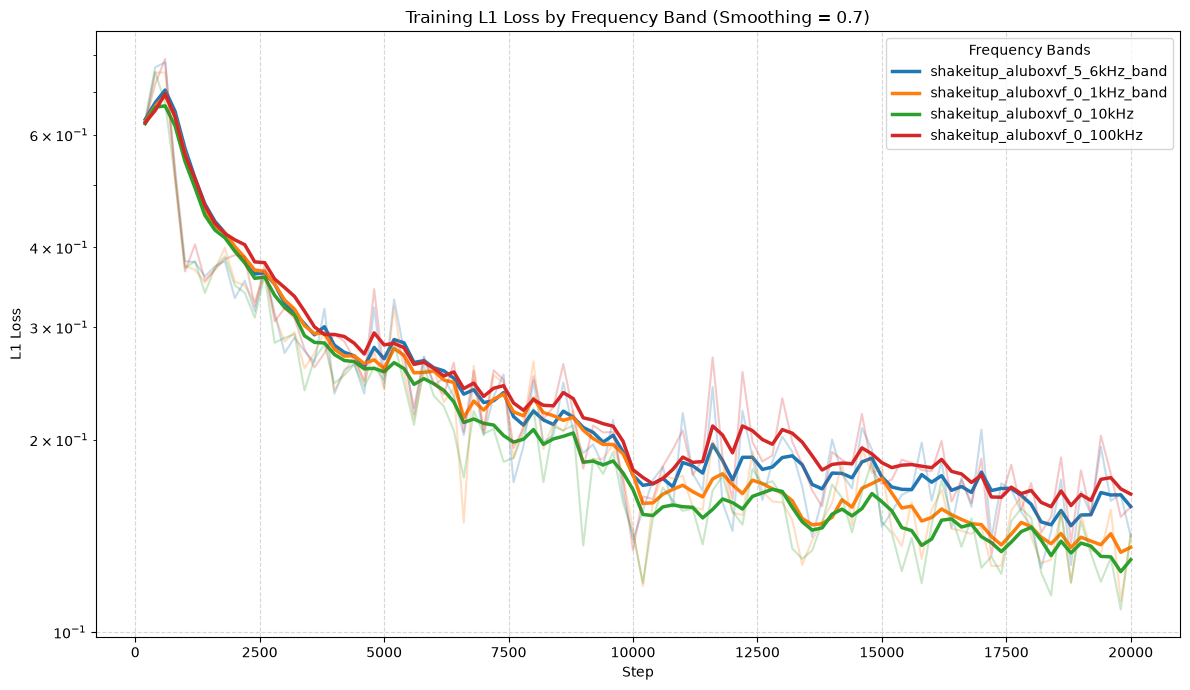

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_wandb_multiline(csv_path, columns_to_plot, step_column='Step', smoothing_weight=0.85):
    """
    Plots smoothed curves for multiple WandB metrics on a single chart.
    """
    # 1. Load the data
    df = pd.read_csv(csv_path)
    
    # 2. Setup the plot
    plt.figure(figsize=(12, 7))
    alpha_ema = 1 - smoothing_weight
    
    # Grab standard matplotlib colors to cycle through
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    # 3. Loop through each column and plot
    for i, col in enumerate(columns_to_plot):
        if col not in df.columns:
            print(f"Warning: Column '{col}' not found in the CSV. Check spelling.")
            continue
            
        # Drop missing values just for this specific series to avoid broken lines
        valid_data = df.dropna(subset=[step_column, col])
        
        # Create a cleaner label for the legend (strips out the repetitive suffix)
        clean_label = col.replace(" - train/l1_loss", "")
        color = colors[i % len(colors)]
        
        # Plot Raw Data (faint line in background)
        plt.plot(
            valid_data[step_column], 
            valid_data[col], 
            color=color, 
            alpha=0.25,        # 25% opacity
            label='_nolegend_' # Hide raw lines from the legend to keep it clean
        )
        
        # Calculate and Plot Smoothed Data (solid foreground line)
        smoothed = valid_data[col].ewm(alpha=alpha_ema, adjust=False).mean()
        plt.plot(
            valid_data[step_column], 
            smoothed, 
            
            color=color, 
            linewidth=2.5, 
            label=clean_label
        )

    plt.yscale('log')

    # 4. Styling
    plt.title(f"Training L1 Loss by Frequency Band (Smoothing = {smoothing_weight})")
    plt.xlabel(step_column)
    plt.ylabel("L1 Loss")
    plt.legend(title="Frequency Bands")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    # Show the plot
    plt.show()

# --- How to use it ---
# These are the exact column headers from the data you provided (ignoring MIN/MAX)
target_columns = [
    "shakeitup_aluboxvf_5_6kHz_band - train/l1_loss",
    "shakeitup_aluboxvf_0_1kHz_band - train/l1_loss",
    "shakeitup_aluboxvf_0_10kHz - train/l1_loss",
    "shakeitup_aluboxvf_0_100kHz - train/l1_loss"
]

# Run the function (Replace 'wandb_export.csv' with your actual file name)
plot_wandb_multiline(
    csv_path='/home/josephrigal/workspace/my_junk/wandb_export/wandb_export_2026-06-15T14_34_10.173+02_00.csv', 
    columns_to_plot=target_columns, 
    smoothing_weight=0.7  # Adjust this based on what looked best in the widget!
)

In [1]:
#plot confusion matrix :
import math
results = {    
    "DGF: nfft=64, 0-10kHz" : [4,4,3,4,3,  0,0,4,2,3,  4,3,2,4,4,  4,4,0,0,4,     4,4,4,4,4,  0,4,4,4,4,  0,-1,0,0,4,  4,0,4,4,4,     3,3,4,3,4, 4,2,2,3,4, 0,0,-1,3,4, 3,0,4,3,4,         3,4,-1,-1,4,  0,4,4,4,0,   4,4,4,4,3,   4,0,4,0,4],
    "DGF: nfft = 512,0-10kHz" : [1,1,1,0,1,  1,1,1,1,1,  1,1,1,1,1,  1,1,1,1,1,     2,3,2,0,2,  2,2,3,2,2,  3,2,3,3,3,  0,0,3,3,2,     3,3,3,4,3, 3,3,3,3,3, 3,3,3,3,3, 3,3,0,3,3,      4,4,4,4,3,  4,4,4,4,4,  0,4,0,4,4,  4,0,4,4,4],
    "DGF: nfft=512, 0-100kHz" :[2,2,0,2,3,   2,3,3,0,3,   3,3,2,3,0,   3,2,2,3,3,      3,3,4,0,4,    4,4,0,0,0,   3,2,2,0,2,   2,0,2,2,3,     3,2,-1,4,0,  0,3,3,0,4,   2,0,3,3,2,   3,-1,3,3,3,      3,3,4,4,4,  3,0,0,2,3,  0,0,3,3,0,  3,3,-1,3,3],
    "DGF: nfft=4096, 0-100kHz" : [1,1,1,1,1,  1,1,1,1,1,  1,0,1,1,1,  1,1,1,1,1,     1,2,2,2,2,  2,2,2,2,2,  2,2,2,2,2,  3,2,2,2,2,     3,3,-1,3,3, 3,0,3,4,-1,   3,0,-1,3,2,   3,3,3,3,0,      4,4,4,4,0,  4,4,0,0,2,  4,4,4,4,4,  4,4,4,3,4]


}
n_conf_math = 4
ep_per_box=20
conf_mats={}

for key,result in results.items() :

    conf_mats[key]=[[0 for i in range(n_conf_math)] for i in range (n_conf_math)]
    ligne_value=-1
    outofbox=0
    grasp_failure=0

    for i in range(len(result)):
        if i%ep_per_box==0:
            ligne_value+=1
        if  result[i] == -1 :
            outofbox+=1
        if result[i] != 0:
            conf_mats[key][ligne_value][result[i]-1]+=1
        else :
            grasp_failure +=1
    print(key)
    print(conf_mats[key])
    print("outofbox : ",outofbox)
    print("grasp_failure : ",grasp_failure)
    print(len(result))



for key, conf_mat in conf_mats.items() : 
    print(key)
    df_cm = pd.DataFrame(conf_mat, range(n_conf_math), range(n_conf_math))
    # plt.figure(figsize=(10,7))
    sn.set(font_scale=2) # for label size
    sn.heatmap(df_cm, annot=True, cmap="Reds",vmin=0, vmax=20,)
    plt.savefig(f"outputs_svg/confusion_matrix_{key.replace(' ', '_')}.svg", format="svg", bbox_inches="tight")
    plt.show()


DGF: nfft=64, 0-10kHz
[[0, 2, 4, 10], [0, 0, 1, 14], [0, 2, 8, 7], [0, 0, 4, 12]]
outofbox :  4
grasp_failure :  16
80
DGF: nfft = 512,0-10kHz
[[19, 0, 0, 0], [0, 9, 8, 0], [0, 0, 18, 1], [0, 0, 1, 16]]
outofbox :  0
grasp_failure :  8
80
DGF: nfft=512, 0-100kHz
[[0, 7, 10, 0], [0, 6, 4, 4], [0, 3, 11, 2], [0, 1, 11, 3]]
outofbox :  3
grasp_failure :  18
80
DGF: nfft=4096, 0-100kHz
[[19, 0, 0, 0], [1, 18, 1, 0], [0, 1, 15, 1], [0, 1, 1, 15]]
outofbox :  3
grasp_failure :  7
80
DGF: nfft=64, 0-10kHz


NameError: name 'pd' is not defined

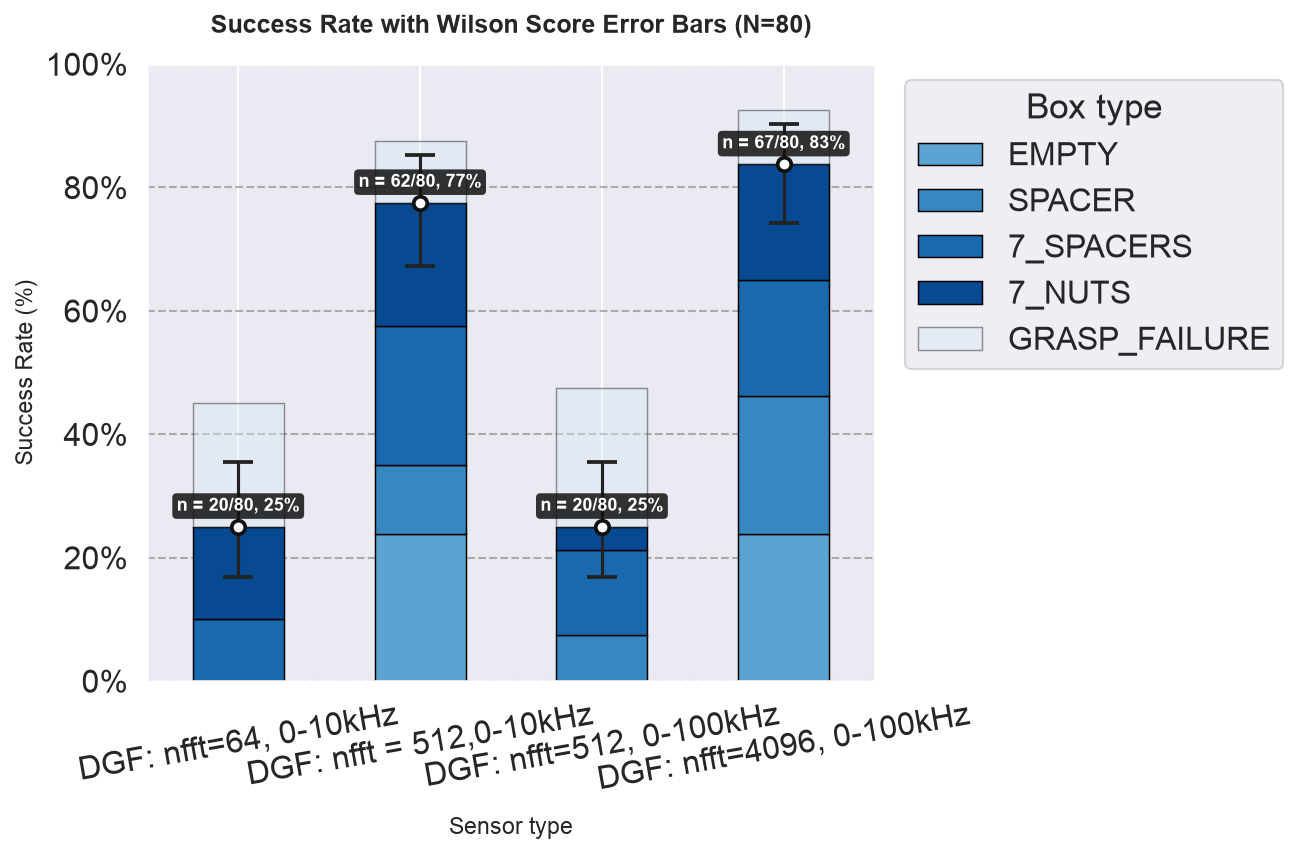

In [ ]:
successes_diff_temp = {
    "DGF: nfft=64, 0-10kHz" : [0, 0, 8, 12, 16],
    "DGF: nfft = 512,0-10kHz" :[19, 9, 18, 16, 8],
    "DGF: nfft=512, 0-100kHz" :[0, 6, 11, 3, 18],
    "DGF: nfft=4096, 0-100kHz" : [19, 18, 15, 15, 7]
}
categories = ["EMPTY", "SPACER", "7_SPACERS", "7_NUTS", "GRASP_FAILURE"]
total_trials = 80

# Build DataFrames
df = pd.DataFrame(successes_diff_temp, index=categories).T

# Total valid trials per method (80 total minus grasp_failure count)
total_trials_w_graspfailure = 80  - df["GRASP_FAILURE"].values

plot_bar(successes_diff_temp, categories, total_trials,name="diff_window_freq")


In [ ]:
#plot confusion matrix :
import math

#    "DGF_LDC" : [2,2,1,1,1,  0,1,1,1,1,  1,2,1,1,2,  1,1,1,2,1,         2,2,2,0,3,  2,2,2,2,2,  0,2,2,2,2,  2,2,2,2,2,          0,2,2,3,2, 2,0,3,3,3,   3,3,2,3,2,   3,3,3,3,3,       4,2,4,4,2, 4,3,4,0,4,   2,4,3,4,4,   4,4,4,4,4],


results = {    
    "DGF_ACC" : [1,1,1,0,1,  1,1,1,1,1,  1,1,1,1,1,  1,1,1,1,1,     2,3,2,0,2,  2,2,3,2,2,  3,2,3,3,3,  0,0,3,3,2,     3,3,3,4,3, 3,3,3,3,3, 3,3,3,3,3, 3,3,0,3,3,      4,4,4,4,3,  4,4,4,4,4,  0,4,0,4,4,  4,0,4,4,4],
    "ACC" :[1,2,1,1,1,  1,1,1,1,2,  1,1,1,1,2,  1,1,1,1,1,     2,2,2,2,2,  2,2,2,2,2,  2,2,0,2,2,  2,2,2,2,2,     3,3,3,4,3, 4,4,3,4,3, 4,3,4,3,0, 3,4,4,4,4,      3,0,4,4,4,  4,4,4,4,2,  3,4,0,4,3,  0,4,0,4,4],
    "NOTACT" : [1,2,0,2,3,  3,0,3,2,3,  3,2,2,3,2,  3,0,3,3,4,     0,4,4,3,4,  4,4,3,2,4,  3,0,3,2,3,  3,2,3,3,2,     3,2,2,3,4, 4,2,2,3,3, 3,3,3,3,2, 0,2,0,4,2,      2,2,1,2,4,  0,0,4,2,3,  3,4,4,2,2,  2,3,3,4,4],
    "LOAD CELL" :[1,1,1,1,1,  2,2,1,1,1,  2,2,2,1,2,  1,2,1,2,1,         2,2,2,1,2,  2,2,2,2,2,  2,2,2,2,1,  1,3,2,2,2,          2,2,3,3,3, 3,3,2,3,2,   2,3,2,3,-1,   2,2,-1,3,2,       3,3,2,3,3, 3,2,2,3,-1,   2,3,3,3,3,   3,2,3,3,2],
    "DGF_LDC" : [2,2,1,1,1,  0,1,1,1,1,  1,2,1,1,2,  1,1,1,2,1,         2,2,2,0,3,  2,2,2,2,2,  0,2,2,2,2,  2,2,2,2,2,          0,2,2,3,2, 2,0,3,3,3,   3,3,2,3,2,   3,3,3,3,3,       4,2,4,4,2, 4,3,4,0,4,   2,4,3,4,4,   4,4,4,4,4],
    "DGF_FRANK" : [1,1,1,1,1,  1,1,1,1,1,  1,1,1,1,1,  1,1,1,1,1,         2,2,2,2,2,  2,2,2,2,2,  2,2,2,2,3,  0,2,2,0,2,          3,3,3,2,3, 3,3,3,3,3,   3,3,2,3,3,   3,3,3,3,3,       3,4,3,3,3, 4,4,3,4,3,   3,4,3,4,3,   4,4,4,3,3],
    "DGF_FRANK_CHEAP" : [0,1,1,1,1,  1,1,1,1,1,  1,1,1,1,1,  1,1,1,1,1,         2,2,2,2,2,  2,2,2,2,2,  2,2,2,1,2,  2,2,2,2,2,          3,3,3,0,3, 3,3,3,3,3,   3,3,3,2,3,  3,3,3,2,3,       4,4,4,4,4, 4,3,4,4,4,   4,4,4,4,4,   4,4,4,4,4],
    "DGF_PASSIF" : [1,1,1,1,1,  1,1,1,2,0,  1,1,1,0,1,  1,1,1,1,1,         2,3,2,3,3,  0,2,2,3,2,  0,0,2,2,3,  4,2,2,2,2,          3,3,3,2,4, 3,3,3,3,3,   3,3,3,4,3,   3,4,3,3,3,       4,3,3,3,2, 3,4,4,3,4,   4,4,3,0,3,   0,4,4,4,4],
    "PZT" : [1,1,1,2,1,  2,1,1,1,1,  1,1,1,1,1,  2,2,1,2,1,         2,2,2,2,2,  2,2,2,2,2,  2,3,2,3,2,  0,2,2,0,2,          3,3,3,3,3, 3,3,3,3,4,   3,4,3,3,3,   3,3,3,3,3,       4,3,3,3,3, 4,4,4,4,4,   3,3,3,3,2,   4,3,4,4,4],
    "PZT_CHEAP" : [2,2,2,1,1,  1,1,2,1,1,  1,2,1,2,1,  2,2,1,1,1,         2,2,0,2,2,  2,2,2,2,2,  2,2,2,1,2,  2,2,2,2,2,          3,3,3,3,3, 3,3,3,3,3,   3,2,3,3,3,  3,3,3,2,2,       4,4,4,4,4, 4,4,4,4,4,   4,4,4,4,3,   4,4,4,4,4],
    "ACC_MEMS" : [1,1,1,1,1,  1,1,1,1,1,  1,1,1,1,1,  1,1,1,1,1,         2,2,2,2,2,  2,2,2,2,2,  2,3,2,3,2,  0,2,2,0,2,          3,3,3,3,3, 3,3,3,3,4,   3,4,3,3,3,   3,3,3,3,3,       4,3,4,3,0, 0,4,4,4,4,   0,0,4,4,0,   0,4,4,4,4],
    "ACC_MEMS_CHEAP" : [2,2,2,1,1,  1,1,2,1,1,  1,2,1,2,1,  2,2,1,1,1,         2,2,0,2,2,  2,2,2,2,2,  2,2,2,1,2,  2,2,2,2,2,          3,3,3,3,3, 3,3,3,3,3,   3,2,3,3,3,  3,3,3,2,2,       4,4,4,4,4, 4,4,4,4,4,   4,4,4,4,3,   4,4,4,4,4],
    "STRAIN_GAUGE" : [3,2,2,2,2,  1,2,1,0,1,  1,1,1,2,3,  1,2,1,3,3,         3,3,2,3,3,  2,3,0,0,2,  2,3,2,3,2,  2,3,3,3,2,          3,2,3,3,3, 3,3,3,3,2,   3,3,3,3,2,   2,3,2,3,3,       4,4,4,4,4, 0,0,0,0,4,   4,4,4,4,4,   4,4,4,4,4],
    
}
n_conf_math = 4
ep_per_box=20
conf_mats={}
grasp_failure = {}
for key,result in results.items() :

    conf_mats[key]=[[0 for i in range(n_conf_math)] for i in range (n_conf_math)]
    ligne_value=-1
    outofbox=0
    grasp_failure[key]=0

    for i in range(len(result)):
        if i%ep_per_box==0:
            ligne_value+=1
        if  result[i] == -1 :
            outofbox+=1
        if result[i] != 0:
            conf_mats[key][ligne_value][result[i]-1]+=1
        else :
            grasp_failure[key] +=1
    print(key)
    print(conf_mats[key])
    print("outofbox : ",outofbox)
print("grasp_failure : ",grasp_failure)



DGF_ACC
[[19, 0, 0, 0], [0, 9, 8, 0], [0, 0, 18, 1], [0, 0, 1, 16]]
outofbox :  0
ACC
[[17, 3, 0, 0], [0, 19, 0, 0], [0, 0, 9, 10], [0, 1, 3, 12]]
outofbox :  0
NOTACT
[[1, 6, 9, 1], [0, 4, 8, 6], [0, 7, 8, 3], [1, 7, 4, 6]]
outofbox :  0
LOAD CELL
[[12, 8, 0, 0], [3, 16, 1, 0], [0, 9, 11, 0], [0, 6, 14, 0]]
outofbox :  3
DGF_LDC
[[14, 5, 0, 0], [0, 17, 1, 0], [0, 6, 12, 0], [0, 3, 2, 14]]
outofbox :  0
DGF_FRANK
[[20, 0, 0, 0], [0, 17, 1, 0], [0, 2, 18, 0], [0, 0, 11, 9]]
outofbox :  0
DGF_FRANK_CHEAP
[[19, 0, 0, 0], [1, 19, 0, 0], [0, 2, 17, 0], [0, 0, 1, 19]]
outofbox :  0
DGF_PASSIF
[[17, 1, 0, 0], [0, 11, 5, 1], [0, 1, 16, 3], [0, 1, 7, 10]]
outofbox :  0
PZT
[[15, 5, 0, 0], [0, 16, 2, 0], [0, 0, 18, 2], [0, 1, 9, 10]]
outofbox :  0
PZT_CHEAP
[[12, 8, 0, 0], [1, 18, 0, 0], [0, 3, 17, 0], [0, 0, 1, 19]]
outofbox :  0
ACC_MEMS
[[20, 0, 0, 0], [0, 16, 2, 0], [0, 0, 18, 2], [0, 0, 2, 12]]
outofbox :  0
ACC_MEMS_CHEAP
[[20, 0, 0, 0], [1, 18, 0, 0], [0, 2, 17, 0], [0, 0, 3, 17]]
outofbo

DGF_ACC


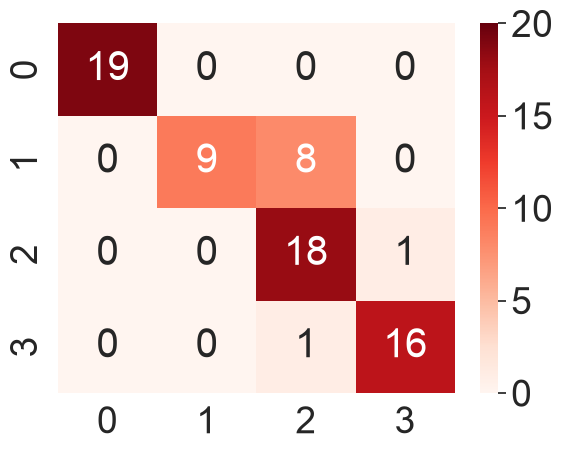

ACC


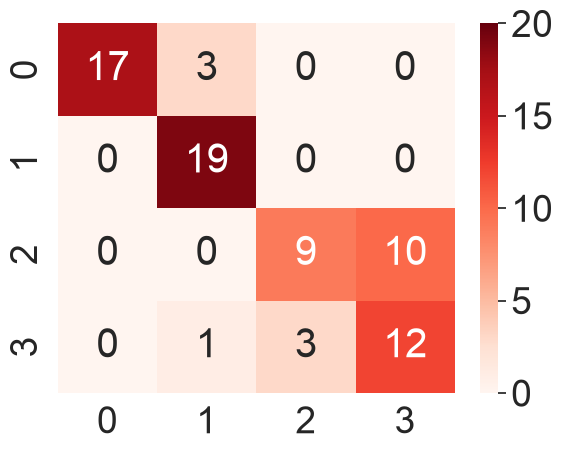

NOTACT


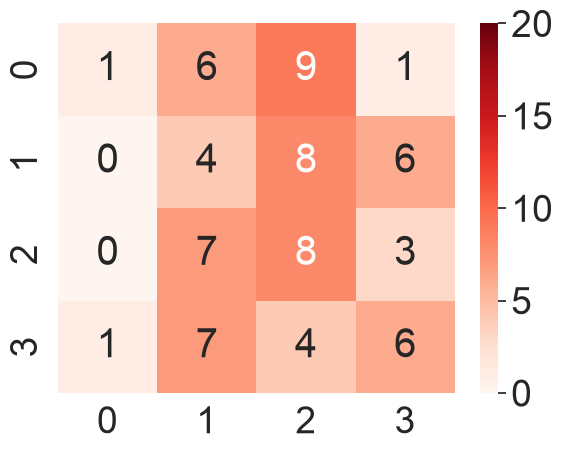

LOAD CELL


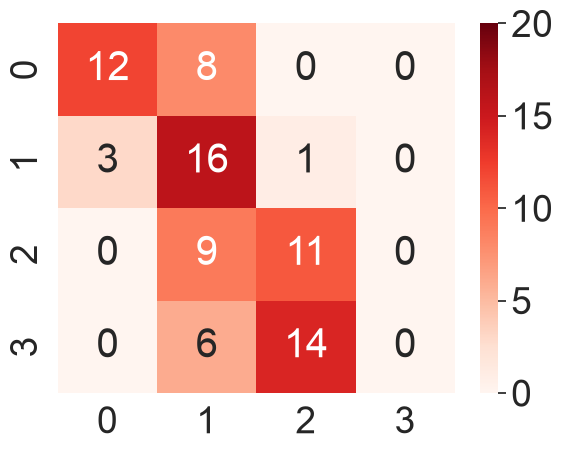

DGF_LDC


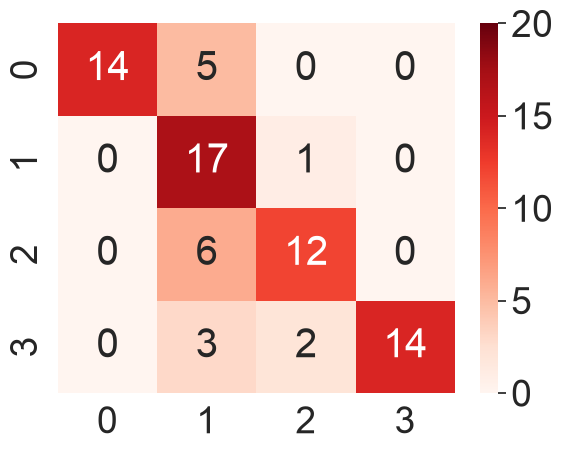

DGF_FRANK


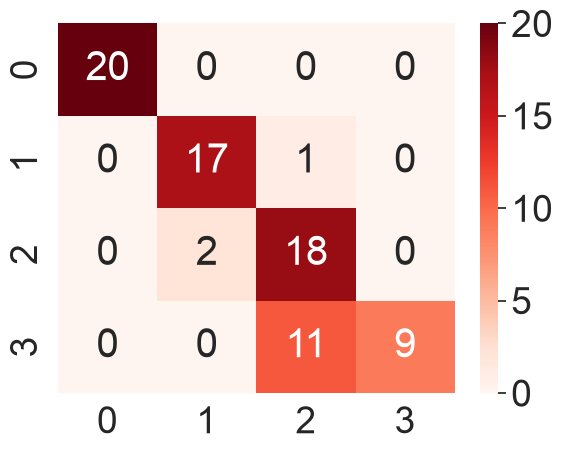

DGF_FRANK_CHEAP


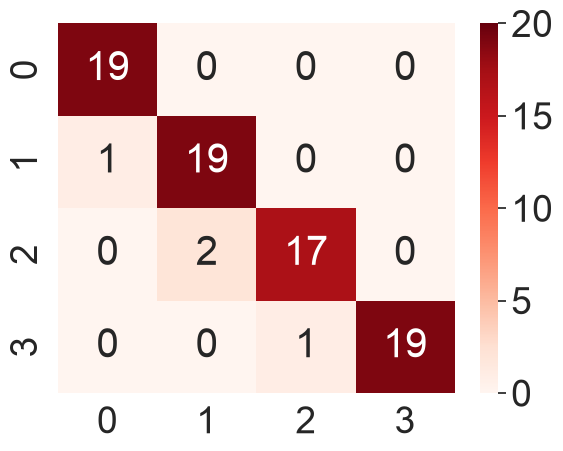

DGF_PASSIF


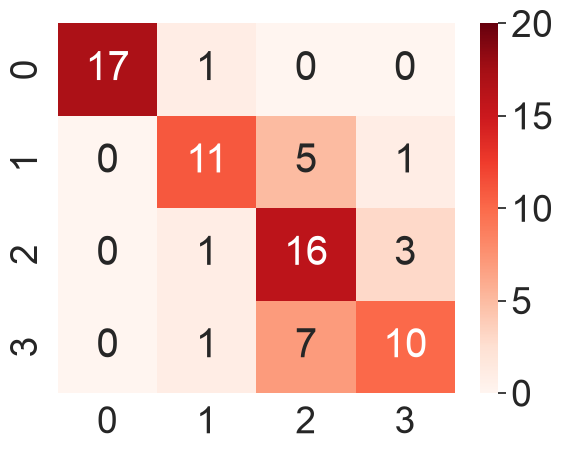

PZT


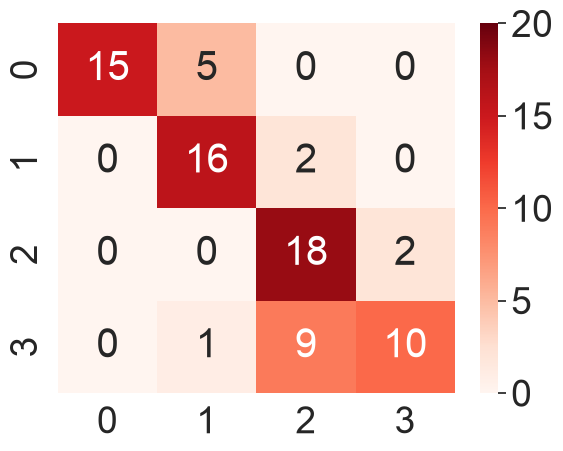

PZT_CHEAP


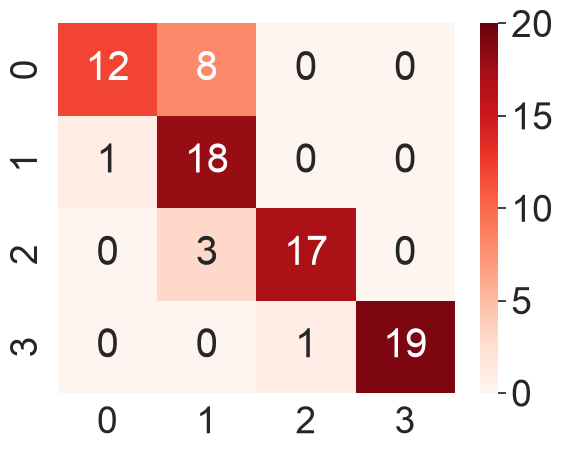

ACC_MEMS


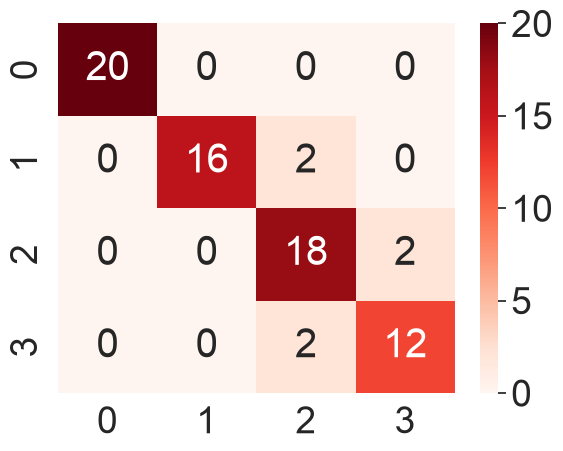

ACC_MEMS_CHEAP


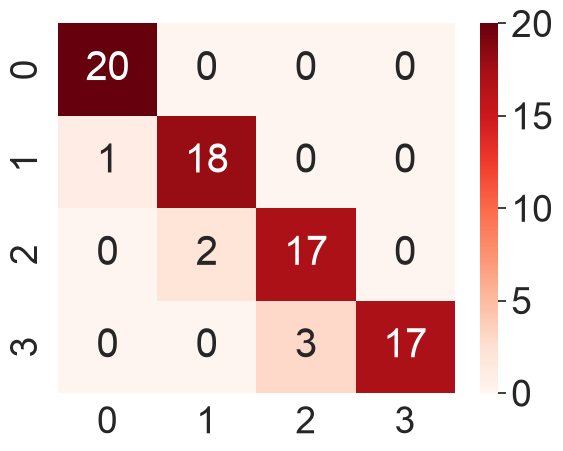

STRAIN_GAUGE


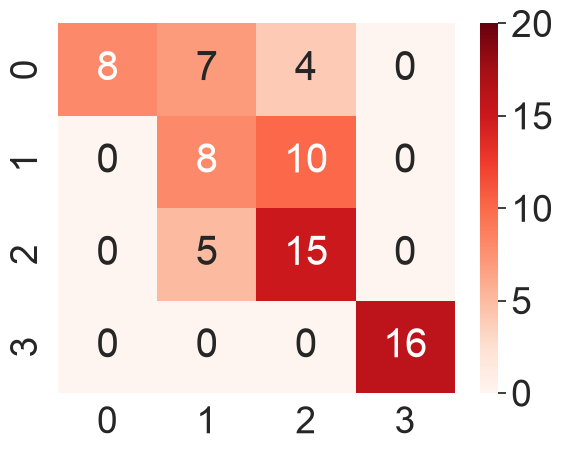

In [8]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt


for key, conf_mat in conf_mats.items() : 
    print(key)
    df_cm = pd.DataFrame(conf_mat, range(n_conf_math), range(n_conf_math))
    # plt.figure(figsize=(10,7))
    sn.set(font_scale=2.4) # for label size
    sn.heatmap(df_cm, annot=True, cmap="Reds",vmin=0, vmax=20)
    plt.savefig(f"outputs_svg/confusion_matrix_{key.replace(' ', '_')}.svg", format="svg", bbox_inches="tight")
    plt.show()

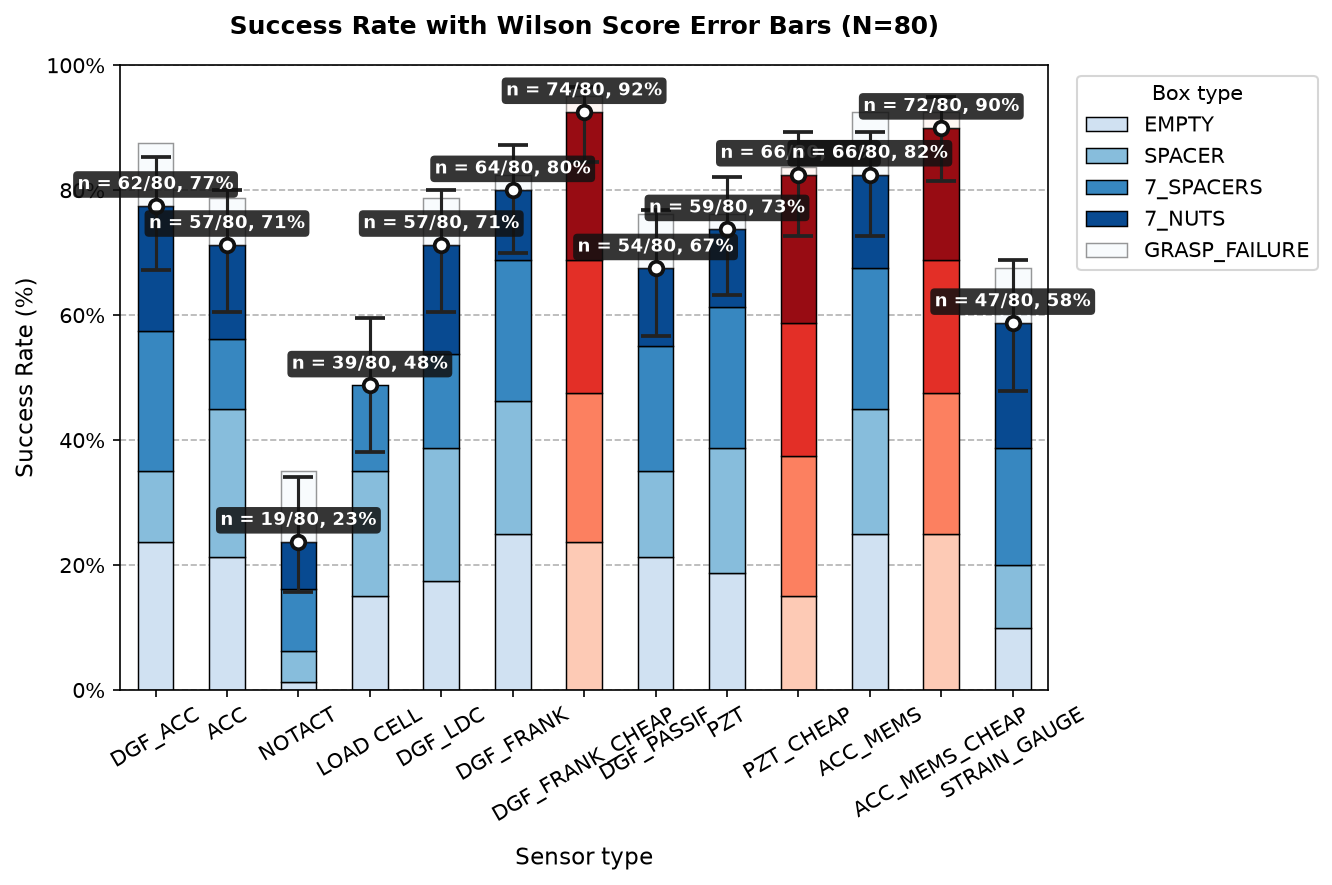

In [7]:
successes_diff_temp = {}

for key,res in conf_mats.items() :
    successes_diff_temp[key] = [res[i][i] for i in range(len(res))] + [grasp_failure[key]]
    
categories = ["EMPTY", "SPACER", "7_SPACERS", "7_NUTS", "GRASP_FAILURE"]
total_trials = 80

# Build DataFrames
df = pd.DataFrame(successes_diff_temp, index=categories).T

# Total valid trials per method (80 total minus grasp_failure count)
total_trials_w_graspfailure = 80  - df["GRASP_FAILURE"].values

plot_bar(successes_diff_temp, categories, total_trials)
